In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

RESULTS = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\results"

# ── Final comparison table ────────────────────────────────────────────────
results = {
    'model': ['Random Forest', 'XGBoost', 'MLP', 'BiLSTM', '1D-CNN', 'Logistic Regression'],
    'f1':        [0.9872, 0.9805, 0.9786, 0.9779, 0.9780, 0.9744],
    'auc_roc':   [0.9952, 0.9958, 0.9929, 0.9924, 0.9922, 0.9892],
    'precision': [0.9989, 0.9622, 0.9999, 0.9999, 0.9999, 1.0000],
    'recall':    [0.9758, 0.9994, 0.9582, 0.9570, 0.9571, 0.9501],
    'accuracy':  [0.9760, 0.9622, 0.9601, 0.9590, 0.9591, 0.9526]
}

df_results = pd.DataFrame(results).set_index('model').sort_values('f1', ascending=False)
print("CIC-IoT-2023 — Final Model Comparison:")
print(df_results.to_string())

df_results.to_csv(os.path.join(RESULTS, "ciciot2023_model_comparison.csv"))
print("\nSaved: ciciot2023_model_comparison.csv")

In [ ]:
# ── SHAP Analysis on Random Forest ───────────────────────────────────────
import shap
import joblib

PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\data\processed"
MODELS    = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\models"

rf = joblib.load(os.path.join(MODELS, "ciciot2023_random_forest.pkl"))
X_test = np.load(os.path.join(PROCESSED, "ciciot2023_X_test.npy"))
feature_names = joblib.load(os.path.join(PROCESSED, "ciciot2023_feature_names.pkl"))

X_test_df = pd.DataFrame(X_test, columns=feature_names)

print("Computing SHAP values...")
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_df), 500, replace=False)
X_sample = X_test_df.iloc[sample_idx]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

# For binary classification RF, shap_values is a list — take class 1
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f"SHAP values shape: {sv.shape}")

# Bar chart
shap.summary_plot(sv, X_sample, feature_names=feature_names,
                  plot_type="bar", max_display=10, show=False)
plt.title("SHAP Mean |SHAP Value| — Random Forest (Top 10)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciot2023_shap_bar.png"), dpi=150)
plt.show()
print("Saved: ciciot2023_shap_bar.png")

# Beeswarm
shap.summary_plot(sv, X_sample, feature_names=feature_names,
                  max_display=10, show=False)
plt.title("SHAP Feature Importance — Random Forest (Top 10)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciot2023_shap_beeswarm.png"), dpi=150)
plt.show()
print("Saved: ciciot2023_shap_beeswarm.png")

# Top 10 features
mean_shap = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(sv).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

mean_shap.to_csv(os.path.join(RESULTS, "ciciot2023_shap_feature_importance.csv"), index=False)
print("\nTop 10 features:")
print(mean_shap.head(10).to_string())

In [ ]:
# Fix sv shape
print(f"sv shape before fix: {sv.shape}")
if sv.ndim == 3:
    sv = sv[:, :, 1]  # take class 1 slice
print(f"sv shape after fix: {sv.shape}")

mean_shap = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(sv).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

mean_shap.to_csv(os.path.join(RESULTS, "ciciot2023_shap_feature_importance.csv"), index=False)
print("\nTop 10 features:")
print(mean_shap.head(10).to_string())

C:\Users\CyrilCorp\AppData\Local\Temp\ipykernel_69200\1382021563.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, feature_names=feature_names,


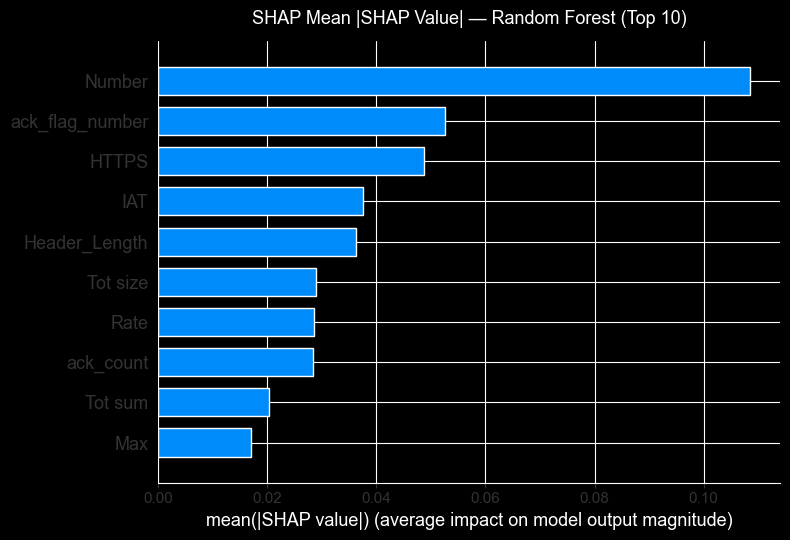

Saved: ciciot2023_shap_bar.png


C:\Users\CyrilCorp\AppData\Local\Temp\ipykernel_69200\1382021563.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, feature_names=feature_names,


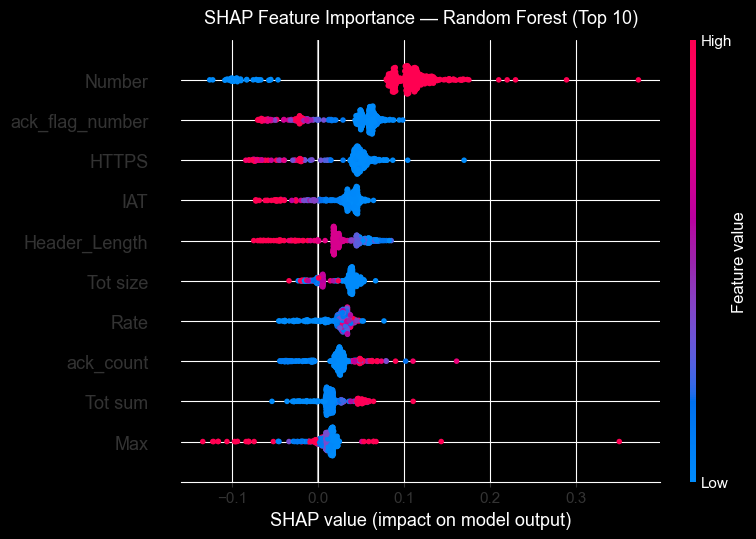

Saved: ciciot2023_shap_beeswarm.png


In [4]:
# Regenerate plots with fixed sv
shap.summary_plot(sv, X_sample, feature_names=feature_names,
                  plot_type="bar", max_display=10, show=False)
plt.title("SHAP Mean |SHAP Value| — Random Forest (Top 10)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciot2023_shap_bar.png"), dpi=150)
plt.show()
print("Saved: ciciot2023_shap_bar.png")

shap.summary_plot(sv, X_sample, feature_names=feature_names,
                  max_display=10, show=False)
plt.title("SHAP Feature Importance — Random Forest (Top 10)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciot2023_shap_beeswarm.png"), dpi=150)
plt.show()
print("Saved: ciciot2023_shap_beeswarm.png")